<a href="https://colab.research.google.com/github/kundalemegha-max/A-B-testing-/blob/main/Hotel_resevation_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [ ]:
df = pd.read_csv("/content/Hotel Reservations (1).csv")

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


In [ ]:
numerical_features = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time','repeated_guest', 'avg_price_per_room', 'no_of_previous_bookings_not_canceled','no_of_special_requests','arrival_month']


In [ ]:
categorical_features = ['type_of_meal_plan','room_type_reserved','market_segment_type']

In [ ]:
df[categorical_features]

,type_of_meal_plan,room_type_reserved,market_segment_type
0,Meal Plan 1,Room_Type 1,Offline
1,Not Selected,Room_Type 1,Online
2,Meal Plan 1,Room_Type 1,Online
3,Meal Plan 1,Room_Type 1,Online
4,Not Selected,Room_Type 1,Online
...,...,...,...
36270,Meal Plan 1,Room_Type 4,Online
36271,Meal Plan 1,Room_Type 1,Online
36272,Meal Plan 1,Room_Type 1,Online
36273,Not Selected,Room_Type 1,Online


In [ ]:
df_cat=pd.get_dummies(df[categorical_features],dtype=int)

In [ ]:
df_cat

,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1
2,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
36271,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
36272,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
36273,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
df[numerical_features]

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,avg_price_per_room,no_of_previous_bookings_not_canceled,no_of_special_requests,arrival_month
0,2,0,1,2,0,224,0,65.00,0,0,10
1,2,0,2,3,0,5,0,106.68,0,1,11
2,1,0,2,1,0,1,0,60.00,0,0,2
3,2,0,0,2,0,211,0,100.00,0,0,5
4,2,0,1,1,0,48,0,94.50,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...
36270,3,0,2,6,0,85,0,167.80,0,1,8
36271,2,0,1,3,0,228,0,90.95,0,2,10
36272,2,0,2,6,0,148,0,98.39,0,2,7
36273,2,0,0,3,0,63,0,94.50,0,0,4


In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_features)

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')


In [ ]:
new_df=pd.concat([df[numerical_features],df_cat],axis=1)

In [ ]:
new_df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,...,0,0,0,0,0,0,0,0,1,0
1,2,0,2,3,0,5,2018,11,6,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,2,1,0,1,2018,2,28,0,...,0,0,0,0,0,0,0,0,0,1
3,2,0,0,2,0,211,2018,5,20,0,...,0,0,0,0,0,0,0,0,0,1
4,2,0,1,1,0,48,2018,4,11,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,3,0,2,6,0,85,2018,8,3,0,...,0,1,0,0,0,0,0,0,0,1
36271,2,0,1,3,0,228,2018,10,17,0,...,0,0,0,0,0,0,0,0,0,1
36272,2,0,2,6,0,148,2018,7,1,0,...,0,0,0,0,0,0,0,0,0,1
36273,2,0,0,3,0,63,2018,4,21,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df['booking_status']

,booking_status
0,Not_Canceled
1,Not_Canceled
2,Canceled
3,Canceled
4,Canceled
...,...
36270,Not_Canceled
36271,Canceled
36272,Not_Canceled
36273,Canceled


In [ ]:
y=df['booking_status'].map({'Not_Canceled':0,'Canceled':1})

In [ ]:
y

,booking_status
0,0
1,0
2,1
3,1
4,1
...,...
36270,0
36271,1
36272,0
36273,1


In [ ]:
x_train, x_test,y_train,y_test = train_test_split(new_df,y,test_size=0.2,random_state=42)

In [ ]:
x_train

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
25629,2,1,2,1,0,26,2017,10,17,0,...,0,0,0,0,0,0,0,0,0,1
14473,2,1,1,1,0,98,2018,7,16,0,...,0,0,0,0,0,0,0,0,0,1
23720,2,0,0,3,0,433,2018,9,8,0,...,0,0,0,0,0,0,0,0,1,0
5843,2,0,2,5,0,195,2018,8,8,0,...,0,0,0,0,0,0,0,0,1,0
18709,1,0,0,2,0,188,2018,6,15,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16850,2,0,2,2,0,43,2017,12,26,0,...,0,0,0,0,0,0,0,0,1,0
6265,1,0,0,2,0,102,2017,10,16,0,...,0,0,0,0,0,0,0,0,0,1
11284,2,0,0,2,0,5,2018,5,24,0,...,0,0,0,0,0,0,0,1,0,0
860,2,0,0,3,0,213,2018,6,7,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
x_train_scaled

array([[0.5       , 0.1       , 0.33333333, ..., 0.        , 0.        ,
        1.        ],
       [0.5       , 0.1       , 0.16666667, ..., 0.        , 0.        ,
        1.        ],
       [0.5       , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.5       , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.5       , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.5       , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers, losses, metrics

In [ ]:
model = Sequential()
l1 = Dense(32,input_shape=(30,), activation="relu") # -- 27 input --- 32 N -- Bias 32
model.add(l1)
l2 = Dense(16,activation='relu')
model.add(l2)
ol = Dense(1,activation="sigmoid")
model.add(ol)


In [ ]:
model = Sequential()
l1 = Dense(32,input_shape=(30,), activation="relu") # -- 30 input --- 32 N -- Bias 32
model.add(l1)
l2 = Dense(16,activation='relu')
model.add(l2)
ol = Dense(1,activation="sigmoid")
model.add(ol)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# AF --- linear to non linear (complex pattern)

# Sigmoid ---> 100 passing sigmoid --> 0-1
# tanh, ReLu, LeakyReLu
# 100 passing to ReLu --> pass as it is --> 100
# -100 passing to ReLu --> 0

In [ ]:
model.compile(optimizer='adam',loss="binary_crossentropy",metrics=['accuracy'])

In [ ]:
df.shape

(36275, 19)

In [ ]:
x_test.shape

(7255, 30)

In [ ]:
x_train.shape

(29020, 30)

In [ ]:
29020/1024 # 28 with 1024 values and this is one batch 29 which is having 348 rows

28.33984375

In [ ]:
1024*30

30720

In [ ]:
1024*23-29020

-5468

In [ ]:
y_train

,booking_status
25629,0
14473,0
23720,1
5843,0
18709,1
...,...
16850,0
6265,1
11284,0
860,1


In [ ]:
model.fit(x=x_train_scaled, y=y_train, epochs=100, batch_size=36275, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4407 - loss: 0.7016
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4647 - loss: 0.6959
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4913 - loss: 0.6906
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5248 - loss: 0.6855
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5599 - loss: 0.6806
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5854 - loss: 0.6760
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5923 - loss: 0.6717
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6113 - loss: 0.6676
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6298 - loss: 0.6636
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6576 - loss: 0.6599
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6741 - loss: 0.6563
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6834 - loss

In [ ]:
from keras.callbacks import History, EarlyStopping
history=History()
model.fit(x=x_train_scaled, y=y_train, epochs=100, batch_size=36275, verbose=1, callbacks=[history])

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7451 - loss: 0.5113
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7478 - loss: 0.5099
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7488 - loss: 0.5085
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7497 - loss: 0.5071
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7494 - loss: 0.5057
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7527 - loss: 0.5043
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7538 - loss: 0.5029
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7552 - loss: 0.5015
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7569 - loss: 0.5002
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7572 - loss: 0.4988
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7579 - loss: 0.4974
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7603 - lo

In [ ]:
history.history['accuracy']

[0.7451412677764893,
 0.7477601766586304,
 0.7488284111022949,
 0.7496898770332336,
 0.7494486570358276,
 0.7526533603668213,
 0.753756046295166,
 0.7552377581596375,
 0.7568917870521545,
 0.7572363615036011,
 0.7579255700111389,
 0.7603377103805542,
 0.7619572877883911,
 0.7624052166938782,
 0.7625086307525635,
 0.763818085193634,
 0.7645761370658875,
 0.7650930285453796,
 0.7661957144737244,
 0.7663335800170898,
 0.7668159604072571,
 0.7681598663330078,
 0.7688146233558655,
 0.7695037722587585,
 0.7699517607688904,
 0.7708132266998291,
 0.7712956666946411,
 0.7715713381767273,
 0.7721226811408997,
 0.772915244102478,
 0.7727773785591125,
 0.7735010385513306,
 0.7735010385513306,
 0.7751206159591675,
 0.7758787274360657,
 0.7763266563415527,
 0.7760165333747864,
 0.7763611078262329,
 0.7767401933670044,
 0.7769469618797302,
 0.7771536707878113,
 0.7778773307800293,
 0.778738796710968,
 0.7788421511650085,
 0.7807374000549316,
 0.7818745970726013,
 0.7821157574653625,
 0.78197795152664

In [ ]:
history.history['loss']

[0.5113418102264404,
 0.5099115967750549,
 0.5084897875785828,
 0.5070860385894775,
 0.5056906342506409,
 0.5043033361434937,
 0.5029204487800598,
 0.5015397071838379,
 0.5001593232154846,
 0.4987756609916687,
 0.49738866090774536,
 0.4959903657436371,
 0.4945824444293976,
 0.49317467212677,
 0.4917580783367157,
 0.49032455682754517,
 0.48888644576072693,
 0.48744648694992065,
 0.48601463437080383,
 0.4846002757549286,
 0.4832042157649994,
 0.48183774948120117,
 0.48049846291542053,
 0.47918543219566345,
 0.4779071509838104,
 0.47667011618614197,
 0.47548142075538635,
 0.4743296504020691,
 0.47319796681404114,
 0.4720836579799652,
 0.47098344564437866,
 0.4698954224586487,
 0.4688108563423157,
 0.46772313117980957,
 0.46664121747016907,
 0.46556833386421204,
 0.4645070433616638,
 0.46346262097358704,
 0.4624369740486145,
 0.4614219069480896,
 0.46041998267173767,
 0.4594351053237915,
 0.4584673345088959,
 0.4575161337852478,
 0.4565775394439697,
 0.4556601643562317,
 0.4547634720802307

Text(0.5, 1.0, 'Model Accuracy')

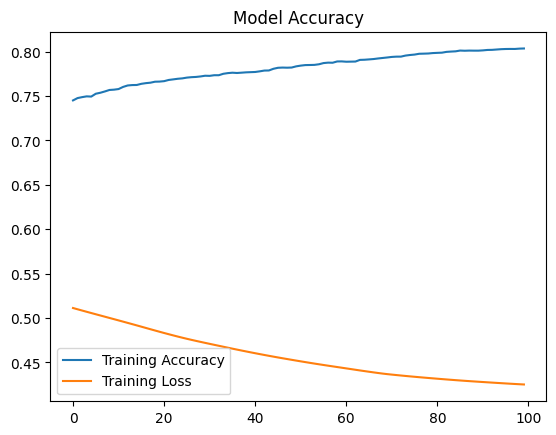

In [ ]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['loss'], label="Training Loss")
plt.legend()

plt.title("Model Accuracy")

In [ ]:
# early stopping
history=History()
early_stop=EarlyStopping(monitor='loss', patience=3, restore_best_weights=True )
model.fit(x=x_train_scaled, y=y_train, epochs=100, batch_size=32, verbose=1, callbacks=[history , early_stop])

Epoch 1/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8054 - loss: 0.4235
Epoch 2/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8100 - loss: 0.4147
Epoch 3/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8110 - loss: 0.4097
Epoch 4/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8133 - loss: 0.4034
Epoch 5/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8167 - loss: 0.3973
Epoch 6/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8207 - loss: 0.3927
Epoch 7/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8212 - loss: 0.3896
Epoch 8/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8241 - loss: 0.3849
Epoch 9/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8274 - loss: 0.3827
Epoch 10/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8261 - loss: 0.3797
Epoch 11/100
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8279 - loss: 0.3776
Epoch 12/100
907/907 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# evalute

In [ ]:
x_test.shape

(7255, 30)

In [ ]:
7255/32

226.71875

In [ ]:
probaVal = model.predict(x_test_scaled)

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
probaVal

array([[0.0003219 ],
       [0.01597629],
       [0.04971956],
       ...,
       [0.00327849],
       [0.03462442],
       [0.05819679]], dtype=float32)

In [ ]:
custom_threshold=0.5

In [ ]:
probaVal>custom_threshold

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [ ]:
custom_Prediction = (probaVal>custom_threshold).astype('int')

In [ ]:
custom_Prediction

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
confusion_matrix(y_test, custom_Prediction)

array([[4370,  469],
       [ 600, 1816]])

In [ ]:
print(classification_report(y_test, custom_Prediction))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      4839
           1       0.79      0.75      0.77      2416

    accuracy                           0.85      7255
   macro avg       0.84      0.83      0.83      7255
weighted avg       0.85      0.85      0.85      7255



In [ ]:
"""
CNN -- convolutional Neural network

---> input : image/Video


ANN --> structed data , rows and columns
        they lack to use other input types, image , audio, video, text

Image input ---> 1920*1080*3 -- 3 RGB(red green blue)

1920*1080*3 --> 6 millions pixels are there

1. image 1 - 1920*1080*3 -- cat
2. image 2 - 1920*1080*3 -- cat
3. image 3 - 1920*1080*3 -- dog
4. image 4 - 1920*1080*3 -- cat
5. image 5 - 1920*1080*3 -- dog


each pixel will range between 0-255

"""

'\nCNN -- convolutional Neural network\n\n---> input : image/Video\n\n\nANN --> structed data , rows and columns\n        they lack to use other input types, image , audio, video, text \n\nImage input ---> 1920*1080*3 -- 3 RGB(red green blue)\n\n1920*1080*3 --> 6 millions pixels are there\n\n1. image 1 - 1920*1080*3 -- cat\n2. image 2 - 1920*1080*3 -- cat\n3. image 3 - 1920*1080*3 -- dog\n4. image 4 - 1920*1080*3 -- cat\n5. image 5 - 1920*1080*3 -- dog\n\n\n'